# Análise do dataset Breast Cancer Wisconsin para comparação de ferramentas AutoML

## Objetivo
O objetivo deste trabalho é analisar o processo de AutoML em quatro ferramentas diferentes: **TPOT**, **H2O**, **AutoGluon** e **AdaNet**, utilizando o dataset **Breast Cancer Wisconsin**.

Este conjunto de dados é usado para classificar tumores mamários em duas categorias:
- **Maligno**
- **Benigno**

A variável alvo é `diagnosis`, enquanto a coluna `id` será removida por não possuir valor preditivo. Antes da aplicação das ferramentas de AutoML, será realizada uma etapa inicial de **limpeza de dados** e **análise exploratória**, de forma a compreender melhor a estrutura do dataset, identificar eventuais problemas e preparar uma base consistente para a comparação entre ferramentas.

## Justificação da abordagem
Antes de aplicar AutoML, é necessário garantir que:
1. os dados estão corretamente carregados;
2. não existem colunas irrelevantes;
3. a variável alvo está num formato adequado;
4. não existem valores em falta;
5. se compreende a distribuição das classes e das variáveis.

Esta etapa é essencial para que a comparação entre ferramentas seja metodologicamente mais justa.

### Importação das Bibliotecas Principais

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configurações visuais
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.3f}")

### Carregamento do dataset

Nesta fase, o dataset é carregado diretamente a partir do ficheiro CSV disponibilizado online.  
Será usada a versão em formato bruto (*raw csv*), adequada à leitura direta em Python com `pandas`.

In [2]:
# URL raw do dataset
url = "https://raw.githubusercontent.com/pplonski/datasets-for-start/master/breast_cancer_wisconsin/data.csv"

# Leitura do ficheiro CSV
df = pd.read_csv(url)

# Visualização inicial
print("Dimensão do dataset:", df.shape)
df.head()

Dimensão do dataset: (569, 32)


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.990,10.380,122.800,1001.000,0.118,0.278,0.300,0.147,0.242,0.079,1.095,0.905,8.589,153.400,0.006,0.049,0.054,0.016,0.030,0.006,25.380,17.330,184.600,2019.000,0.162,0.666,0.712,0.265,0.460,0.119
1,842517,M,20.570,17.770,132.900,1326.000,0.085,0.079,0.087,0.070,0.181,0.057,0.543,0.734,3.398,74.080,0.005,0.013,0.019,0.013,0.014,0.004,24.990,23.410,158.800,1956.000,0.124,0.187,0.242,0.186,0.275,0.089
2,84300903,M,19.690,21.250,130.000,1203.000,0.110,0.160,0.197,0.128,0.207,0.060,0.746,0.787,4.585,94.030,0.006,0.040,0.038,0.021,0.022,0.005,23.570,25.530,152.500,1709.000,0.144,0.424,0.450,0.243,0.361,0.088
3,84348301,M,11.420,20.380,77.580,386.100,0.142,0.284,0.241,0.105,0.260,0.097,0.496,1.156,3.445,27.230,0.009,0.075,0.057,0.019,0.060,0.009,14.910,26.500,98.870,567.700,0.210,0.866,0.687,0.258,0.664,0.173
4,84358402,M,20.290,14.340,135.100,1297.000,0.100,0.133,0.198,0.104,0.181,0.059,0.757,0.781,5.438,94.440,0.011,0.025,0.057,0.019,0.018,0.005,22.540,16.670,152.200,1575.000,0.137,0.205,0.400,0.163,0.236,0.077


## Observação inicial do dataset

O dataset contém observações relativas a características dos núcleos celulares obtidas a partir de imagens digitalizadas.

A seguir, será feita uma inspeção inicial à estrutura dos dados, incluindo:
- nomes das colunas;
- tipos de dados;
- primeiras observações;
- presença de valores em falta.

In [3]:
# Ver primeiras linhas
print("Primeiras 5 linhas:")
display(df.head())

# Ver nomes das colunas
print("\nColunas do dataset:")
print(df.columns.tolist())

# Informação geral
print("\nInformação geral:")
df.info()

# Estatísticas descritivas
print("\nEstatísticas descritivas:")
display(df.describe())

Primeiras 5 linhas:


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.990,10.380,122.800,1001.000,0.118,0.278,0.300,0.147,0.242,0.079,1.095,0.905,8.589,153.400,0.006,0.049,0.054,0.016,0.030,0.006,25.380,17.330,184.600,2019.000,0.162,0.666,0.712,0.265,0.460,0.119
1,842517,M,20.570,17.770,132.900,1326.000,0.085,0.079,0.087,0.070,0.181,0.057,0.543,0.734,3.398,74.080,0.005,0.013,0.019,0.013,0.014,0.004,24.990,23.410,158.800,1956.000,0.124,0.187,0.242,0.186,0.275,0.089
2,84300903,M,19.690,21.250,130.000,1203.000,0.110,0.160,0.197,0.128,0.207,0.060,0.746,0.787,4.585,94.030,0.006,0.040,0.038,0.021,0.022,0.005,23.570,25.530,152.500,1709.000,0.144,0.424,0.450,0.243,0.361,0.088
3,84348301,M,11.420,20.380,77.580,386.100,0.142,0.284,0.241,0.105,0.260,0.097,0.496,1.156,3.445,27.230,0.009,0.075,0.057,0.019,0.060,0.009,14.910,26.500,98.870,567.700,0.210,0.866,0.687,0.258,0.664,0.173
4,84358402,M,20.290,14.340,135.100,1297.000,0.100,0.133,0.198,0.104,0.181,0.059,0.757,0.781,5.438,94.440,0.011,0.025,0.057,0.019,0.018,0.005,22.540,16.670,152.200,1575.000,0.137,0.205,0.400,0.163,0.236,0.077



Colunas do dataset:
['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst']

Informação geral:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean   

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000
mean,30371831.432,14.127,19.290,91.969,654.889,0.096,0.104,0.089,0.049,0.181,0.063,0.405,1.217,2.866,40.337,0.007,0.025,0.032,0.012,0.021,0.004,16.269,25.677,107.261,880.583,0.132,0.254,0.272,0.115,0.290,0.084
std,125020585.612,3.524,4.301,24.299,351.914,0.014,0.053,0.080,0.039,0.027,0.007,0.277,0.552,2.022,45.491,0.003,0.018,0.030,0.006,0.008,0.003,4.833,6.146,33.603,569.357,0.023,0.157,0.209,0.066,0.062,0.018
min,8670.000,6.981,9.710,43.790,143.500,0.053,0.019,0.000,0.000,0.106,0.050,0.112,0.360,0.757,6.802,0.002,0.002,0.000,0.000,0.008,0.001,7.930,12.020,50.410,185.200,0.071,0.027,0.000,0.000,0.157,0.055
25%,869218.000,11.700,16.170,75.170,420.300,0.086,0.065,0.030,0.020,0.162,0.058,0.232,0.834,1.606,17.850,0.005,0.013,0.015,0.008,0.015,0.002,13.010,21.080,84.110,515.300,0.117,0.147,0.115,0.065,0.250,0.071
50%,906024.000,13.370,18.840,86.240,551.100,0.096,0.093,0.062,0.034,0.179,0.062,0.324,1.108,2.287,24.530,0.006,0.020,0.026,0.011,0.019,0.003,14.970,25.410,97.660,686.500,0.131,0.212,0.227,0.100,0.282,0.080
75%,8813129.000,15.780,21.800,104.100,782.700,0.105,0.130,0.131,0.074,0.196,0.066,0.479,1.474,3.357,45.190,0.008,0.032,0.042,0.015,0.023,0.005,18.790,29.720,125.400,1084.000,0.146,0.339,0.383,0.161,0.318,0.092
max,911320502.000,28.110,39.280,188.500,2501.000,0.163,0.345,0.427,0.201,0.304,0.097,2.873,4.885,21.980,542.200,0.031,0.135,0.396,0.053,0.079,0.030,36.040,49.540,251.200,4254.000,0.223,1.058,1.252,0.291,0.664,0.207


### Limpeza inicial dos dados

Nesta etapa será realizada a preparação inicial dos dados, com especial destaque para:

- remoção da coluna `id`, por não ter utilidade preditiva;
- verificação de valores nulos;
- confirmação da variável alvo;
- preparação da coluna `diagnosis` para modelação.

A remoção da coluna `id` é importante porque representa apenas um identificador único e não contribui para a classificação do tumor.

In [4]:
def limpar_dados(df):            # Remove colunas irrelevantes, verifica valores nulos e cria a versão numérica da variável alvo.
    data = df.copy()

    # Remover a coluna 'id'
    if "id" in data.columns:
        data = data.drop(columns=["id"])
        print("Coluna 'id' removida com sucesso.")
    else:
        print("A coluna 'id' não existe no dataset.")

    print("Nova dimensão do dataset:", data.shape)

    print("\nValores nulos por coluna:")
    print(data.isnull().sum())

    print("\nTotal de valores nulos no dataset:", data.isnull().sum().sum())

    # Converter target para formato numérico
    data["diagnosis_num"] = data["diagnosis"].map({"M": 1, "B": 0})

    print("\nDistribuição original da variável 'diagnosis':")
    print(data["diagnosis"].value_counts())

    print("\nDistribuição da variável numérica:")
    print(data["diagnosis_num"].value_counts())

    return data

data = limpar_dados(df)
display(data.head())

Coluna 'id' removida com sucesso.
Nova dimensão do dataset: (569, 31)

Valores nulos por coluna:
diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtyp

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,diagnosis_num
0,M,17.990,10.380,122.800,1001.000,0.118,0.278,0.300,0.147,0.242,0.079,1.095,0.905,8.589,153.400,0.006,0.049,0.054,0.016,0.030,0.006,25.380,17.330,184.600,2019.000,0.162,0.666,0.712,0.265,0.460,0.119,1
1,M,20.570,17.770,132.900,1326.000,0.085,0.079,0.087,0.070,0.181,0.057,0.543,0.734,3.398,74.080,0.005,0.013,0.019,0.013,0.014,0.004,24.990,23.410,158.800,1956.000,0.124,0.187,0.242,0.186,0.275,0.089,1
2,M,19.690,21.250,130.000,1203.000,0.110,0.160,0.197,0.128,0.207,0.060,0.746,0.787,4.585,94.030,0.006,0.040,0.038,0.021,0.022,0.005,23.570,25.530,152.500,1709.000,0.144,0.424,0.450,0.243,0.361,0.088,1
3,M,11.420,20.380,77.580,386.100,0.142,0.284,0.241,0.105,0.260,0.097,0.496,1.156,3.445,27.230,0.009,0.075,0.057,0.019,0.060,0.009,14.910,26.500,98.870,567.700,0.210,0.866,0.687,0.258,0.664,0.173,1
4,M,20.290,14.340,135.100,1297.000,0.100,0.133,0.198,0.104,0.181,0.059,0.757,0.781,5.438,94.440,0.011,0.025,0.057,0.019,0.018,0.005,22.540,16.670,152.200,1575.000,0.137,0.205,0.400,0.163,0.236,0.077,1


### Separação entre variáveis explicativas e variável alvo

Para as etapas seguintes, será útil distinguir:
- as **features** (variáveis independentes);
- a **target** (variável dependente).

A coluna `diagnosis` será mantida apenas para referência visual nesta fase, mas a variável usada para modelação será `diagnosis_num`.

In [5]:
def separar_features_target(data):          #Separa as variáveis explicativas da variável alvo.
    X = data.drop(columns=["diagnosis", "diagnosis_num"])
    y = data["diagnosis_num"]

    print("Dimensão de X:", X.shape)
    print("Dimensão de y:", y.shape)

    print("\nPrimeiras colunas de X:")
    print(X.columns.tolist()[:10])

    print("\nPrimeiros valores de y:")
    print(y.head())

    return X, y

X, y = separar_features_target(data)

Dimensão de X: (569, 30)
Dimensão de y: (569,)

Primeiras colunas de X:
['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean']

Primeiros valores de y:
0    1
1    1
2    1
3    1
4    1
Name: diagnosis_num, dtype: int64


### Análise da distribuição das classes

A distribuição da variável alvo é importante porque permite perceber se existe ou não desequilíbrio entre classes.  
Num problema de classificação médica, esta análise é particularmente relevante, uma vez que a simples accuracy pode ser insuficiente para avaliar corretamente o desempenho dos modelos.

Contagem por classe:
diagnosis
B    357
M    212
Name: count, dtype: int64

Percentagem por classe:
diagnosis
B   62.740
M   37.260
Name: proportion, dtype: float64


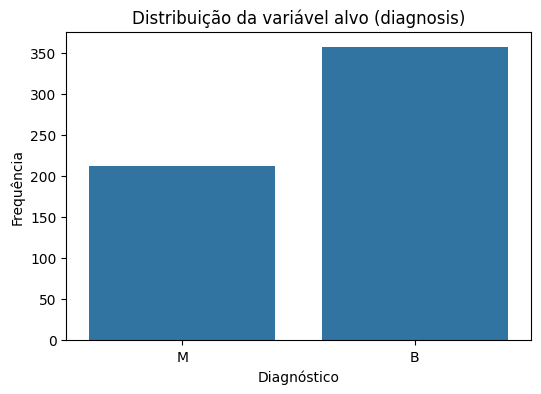

In [6]:
def analisar_classes(data):                #Analisa a distribuição da variável alvo.
    class_counts = data["diagnosis"].value_counts()
    class_percent = data["diagnosis"].value_counts(normalize=True) * 100

    print("Contagem por classe:")
    print(class_counts)

    print("\nPercentagem por classe:")
    print(class_percent.round(2))

    plt.figure(figsize=(6,4))
    sns.countplot(data=data, x="diagnosis")
    plt.title("Distribuição da variável alvo (diagnosis)")
    plt.xlabel("Diagnóstico")
    plt.ylabel("Frequência")
    plt.show()

analisar_classes(data)

### Estatísticas descritivas e análise exploratória

A análise exploratória permite compreender melhor o comportamento das variáveis, identificar diferenças de escala, possíveis outliers e relações entre atributos.

Esta etapa é importante porque algumas ferramentas AutoML lidam bem com estas características de forma automática, enquanto outras podem ser mais sensíveis à forma como os dados entram no processo.

In [7]:
def estatisticas_descritivas(X):                        #Mostra estatísticas descritivas das features.
    display(X.describe().T)

estatisticas_descritivas(X)

,count,mean,std,min,25%,50%,75%,max
radius_mean,569.000,14.127,3.524,6.981,11.700,13.370,15.780,28.110
texture_mean,569.000,19.290,4.301,9.710,16.170,18.840,21.800,39.280
perimeter_mean,569.000,91.969,24.299,43.790,75.170,86.240,104.100,188.500
area_mean,569.000,654.889,351.914,143.500,420.300,551.100,782.700,2501.000
smoothness_mean,569.000,0.096,0.014,0.053,0.086,0.096,0.105,0.163
compactness_mean,569.000,0.104,0.053,0.019,0.065,0.093,0.130,0.345
concavity_mean,569.000,0.089,0.080,0.000,0.030,0.062,0.131,0.427
concave points_mean,569.000,0.049,0.039,0.000,0.020,0.034,0.074,0.201
symmetry_mean,569.000,0.181,0.027,0.106,0.162,0.179,0.196,0.304
fractal_dimension_mean,569.000,0.063,0.007,0.050,0.058,0.062,0.066,0.097


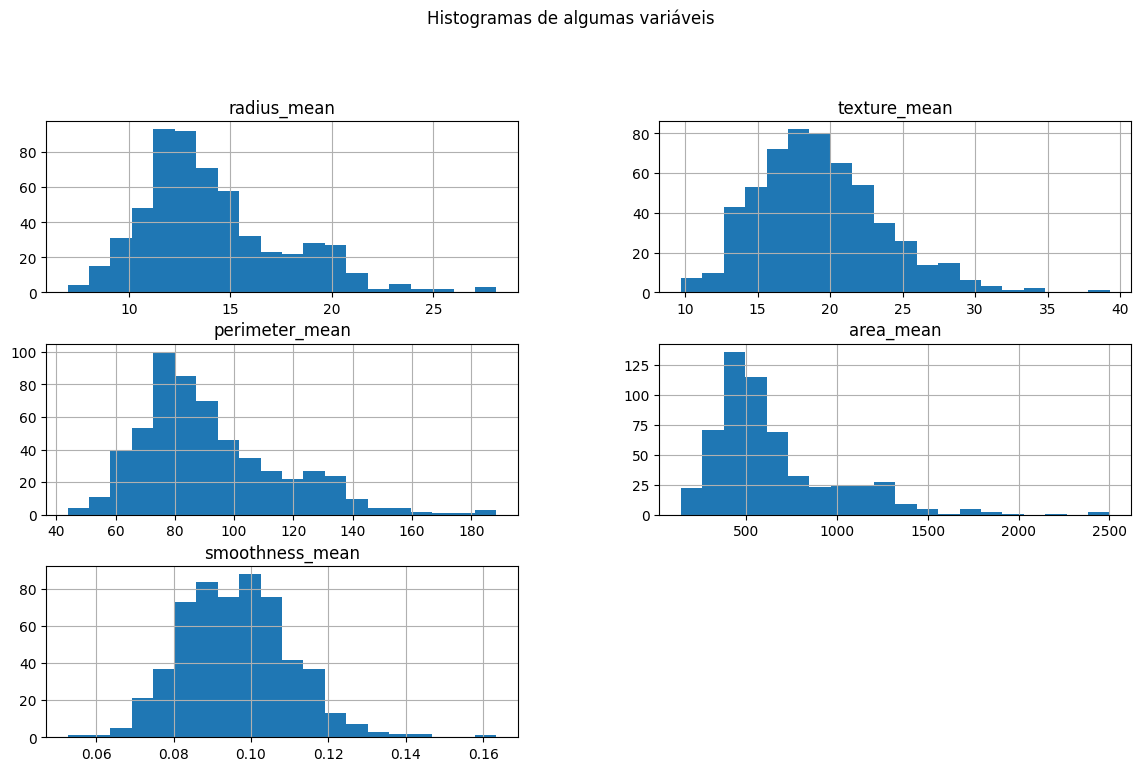

In [8]:
# Histogramas de algumas featurea
def plotar_histogramas(X, features_to_plot=None):
    if features_to_plot is None:
        features_to_plot = ["radius_mean", "texture_mean", "perimeter_mean", "area_mean", "smoothness_mean"]

    X[features_to_plot].hist(figsize=(14, 8), bins=20)
    plt.suptitle("Histogramas de algumas variáveis", y=1.02)
    plt.show()

plotar_histogramas(X)

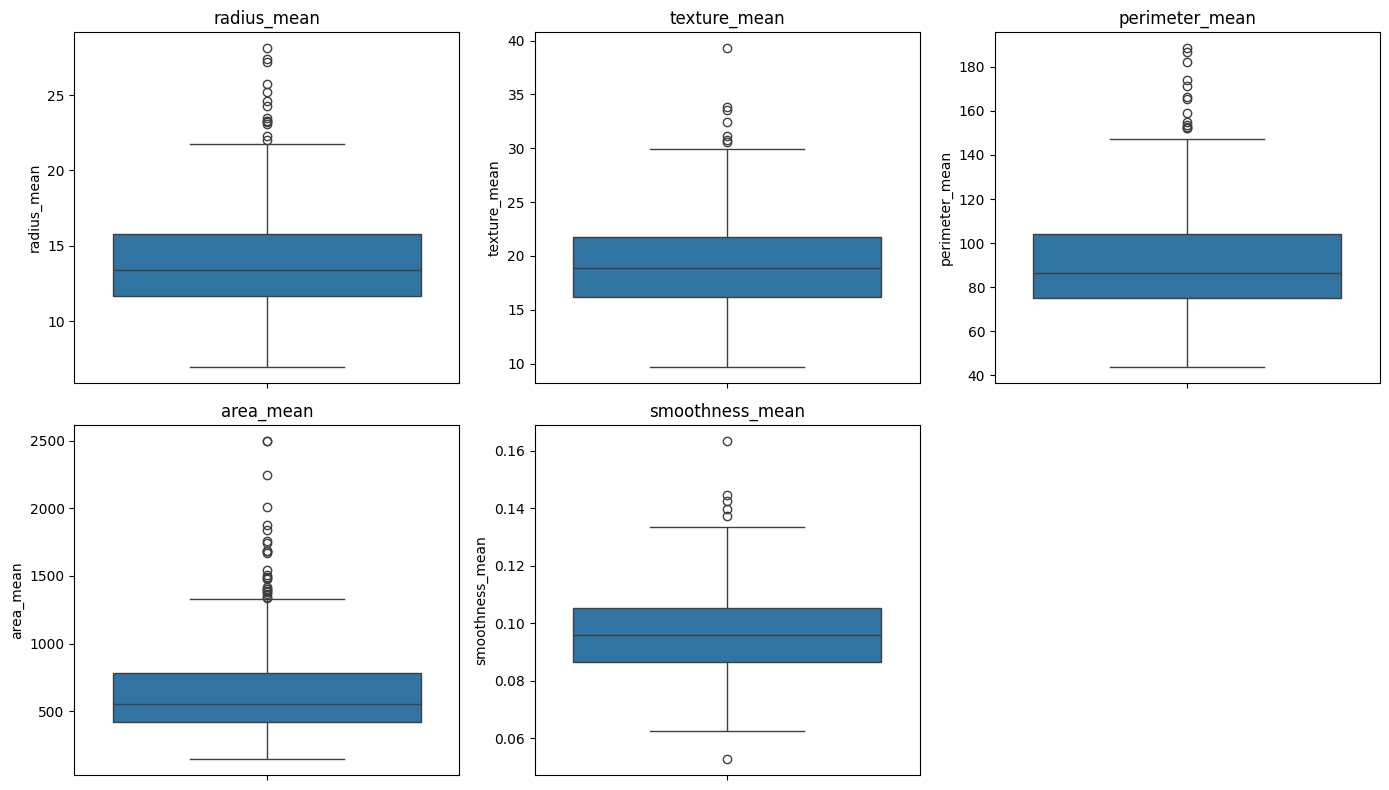

In [9]:
# BoxPlots de algumas features
def plotar_boxplots(X, features_to_plot=None):
    if features_to_plot is None:
        features_to_plot = ["radius_mean", "texture_mean", "perimeter_mean", "area_mean", "smoothness_mean"]

    plt.figure(figsize=(14, 8))
    for i, col in enumerate(features_to_plot, 1):
        plt.subplot(2, 3, i)
        sns.boxplot(y=X[col])
        plt.title(col)

    plt.tight_layout()
    plt.show()

plotar_boxplots(X)

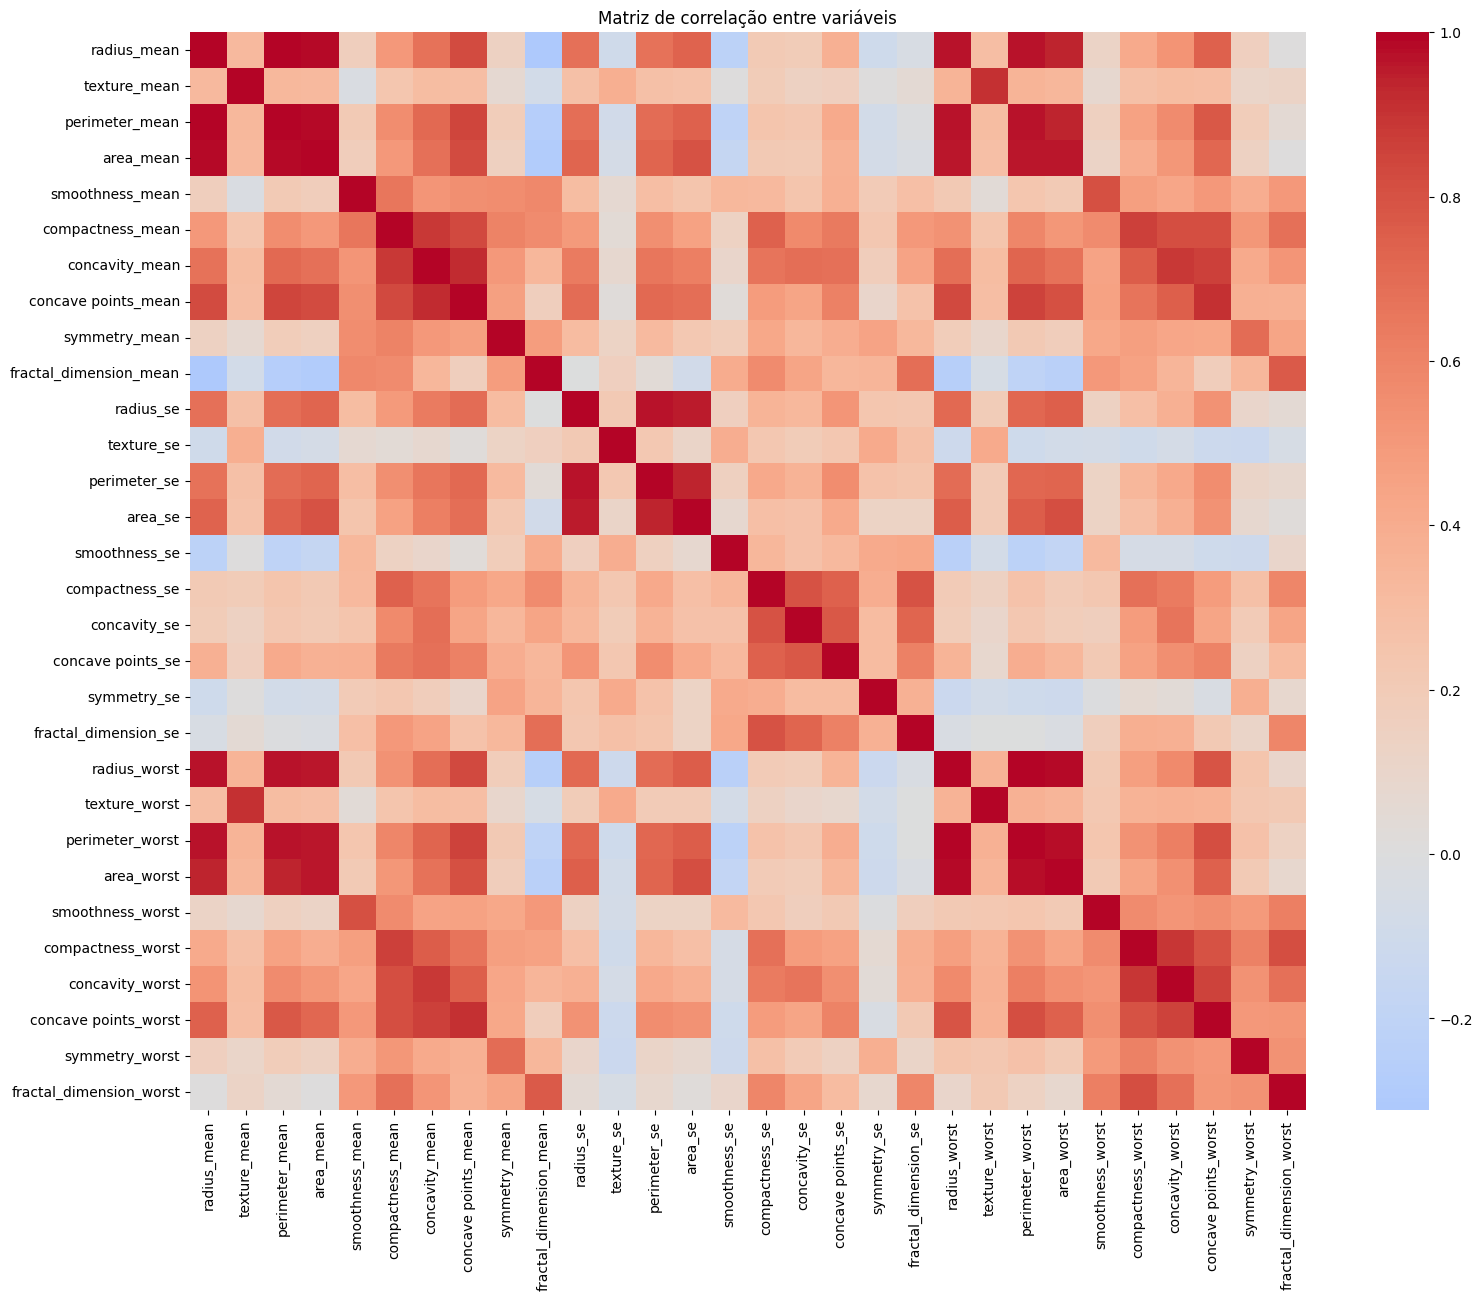

In [10]:
# Matriz de Correlação
def matriz_correlacao(X):
    corr_matrix = X.corr()

    plt.figure(figsize=(18, 14))
    sns.heatmap(corr_matrix, cmap="coolwarm", center=0)
    plt.title("Matriz de correlação entre variáveis")
    plt.show()

    return corr_matrix

corr_matrix = matriz_correlacao(X)

In [11]:
# Coreelações mais elevadas
def top_correlacoes(corr_matrix, top_n=20):
    corr_pairs = corr_matrix.abs().unstack().sort_values(ascending=False)
    corr_pairs = corr_pairs[corr_pairs < 1]

    print(f"Top {top_n} correlações mais elevadas:")
    print(corr_pairs.head(top_n))

top_correlacoes(corr_matrix)

Top 20 correlações mais elevadas:
radius_mean      perimeter_mean    0.998
perimeter_mean   radius_mean       0.998
radius_worst     perimeter_worst   0.994
perimeter_worst  radius_worst      0.994
area_mean        radius_mean       0.987
radius_mean      area_mean         0.987
perimeter_mean   area_mean         0.987
area_mean        perimeter_mean    0.987
area_worst       radius_worst      0.984
radius_worst     area_worst        0.984
perimeter_worst  area_worst        0.978
area_worst       perimeter_worst   0.978
perimeter_se     radius_se         0.973
radius_se        perimeter_se      0.973
perimeter_worst  perimeter_mean    0.970
perimeter_mean   perimeter_worst   0.970
radius_mean      radius_worst      0.970
radius_worst     radius_mean       0.970
                 perimeter_mean    0.969
perimeter_mean   radius_worst      0.969
dtype: float64


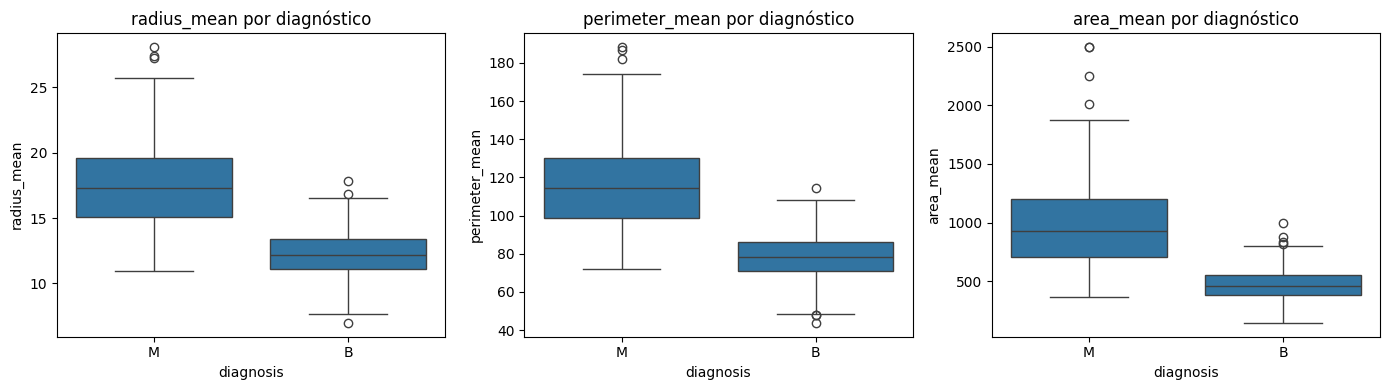

In [12]:
# Comparação de features por classe

def comparar_features_por_classe(data):
    plt.figure(figsize=(14, 4))

    plt.subplot(1, 3, 1)
    sns.boxplot(data=data, x="diagnosis", y="radius_mean")
    plt.title("radius_mean por diagnóstico")

    plt.subplot(1, 3, 2)
    sns.boxplot(data=data, x="diagnosis", y="perimeter_mean")
    plt.title("perimeter_mean por diagnóstico")

    plt.subplot(1, 3, 3)
    sns.boxplot(data=data, x="diagnosis", y="area_mean")
    plt.title("area_mean por diagnóstico")

    plt.tight_layout()
    plt.show()

comparar_features_por_classe(data)

### Conclusão da análise exploratória

A análise exploratória inicial permitiu retirar várias observações importantes:

1. a coluna `id` não tem utilidade preditiva e foi removida;
2. o dataset não apresenta valores nulos;
3. a variável alvo `diagnosis` foi convertida para formato numérico;
4. todas as variáveis explicativas são numéricas;
5. existem diferenças de escala entre atributos;
6. algumas variáveis apresentam correlações elevadas;
7. determinadas features parecem distinguir bem tumores benignos e malignos.

Estes resultados mostram que o dataset se encontra relativamente limpo e adequado para a aplicação de ferramentas AutoML, embora a análise de métricas apropriadas continue a ser importante devido ao contexto médico do problema.

# Preparação para modelação

Antes da aplicação das ferramentas de AutoML, será feita a divisão entre treino e teste.  
Para garantir uma comparação justa entre TPOT, H2O, AutoGluon e AdaNet, será usada a mesma divisão de dados em todas as abordagens.

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

def preparar_dados_modelacao(X, y, test_size=0.20, random_state=42):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=test_size,
        random_state=random_state,
        stratify=y
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    print("X_train:", X_train.shape)
    print("X_test :", X_test.shape)
    print("y_train:", y_train.shape)
    print("y_test :", y_test.shape)

    print("\nDistribuição y_train:")
    print(y_train.value_counts(normalize=True).round(3))

    print("\nDistribuição y_test:")
    print(y_test.value_counts(normalize=True).round(3))

    return X_train, X_test, y_train, y_test, X_train_scaled, X_test_scaled, scaler

X_train, X_test, y_train, y_test, X_train_scaled, X_test_scaled, scaler = preparar_dados_modelacao(X, y)

X_train: (455, 30)
X_test : (114, 30)
y_train: (455,)
y_test : (114,)

Distribuição y_train:
diagnosis_num
0   0.626
1   0.374
Name: proportion, dtype: float64

Distribuição y_test:
diagnosis_num
0   0.632
1   0.368
Name: proportion, dtype: float64


## Base comum de avaliação

Para comparar corretamente as ferramentas AutoML, será usada uma função comum de avaliação com as seguintes métricas:
- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC
- Matriz de confusão

Desta forma, os resultados obtidos por cada ferramenta poderão ser analisados com maior consistência.

In [55]:
# função de avaliação comum
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)

def avaliar_modelo(nome_modelo, y_true, y_pred, y_prob=None):
    resultados = {}

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred)

    resultados["Ferramenta"] = nome_modelo
    resultados["Accuracy"] = acc
    resultados["Precision"] = prec
    resultados["Recall"] = rec
    resultados["F1-score"] = f1
    resultados["Confusion_Matrix"] = cm

    print("=" * 60)
    print(f"Modelo: {nome_modelo}")
    print("=" * 60)
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-score : {f1:.4f}")

    if y_prob is not None:
        try:
            auc = roc_auc_score(y_true, y_prob)
            resultados["ROC-AUC"] = auc
            print(f"ROC-AUC  : {auc:.4f}")
        except:
            resultados["ROC-AUC"] = None
    else:
        resultados["ROC-AUC"] = None

    print("\nRelatório de classificação:")
    print(classification_report(y_true, y_pred))

    print("Matriz de confusão:")
    print(cm)

    return resultados

## Funções por ferramenta

Para tornar o código mais organizado e facilitar a comparação, cada ferramenta será executada através de uma função própria.  
Desta forma, o processo fica mais limpo, reutilizável e fácil de interpretar.

### TPOT

In [56]:
def executar_tpot(X_train_scaled, X_test_scaled, y_train, y_test,
                  cv=5, random_state=42, max_time_mins=5):

    import numpy as np
    from tpot import TPOTClassifier

    y_train_local = np.array(y_train)
    y_test_local = np.array(y_test)

    tpot = TPOTClassifier(
        search_space="linear",      # compatível com a API atual
        scorers=["f1"],             # já não é "scoring"
        scorers_weights=[1],
        cv=cv,
        preprocessing=False,
        max_time_mins=max_time_mins,
        max_eval_time_mins=2,
        n_jobs=1,                   # mais seguro em Jupyter
        validation_strategy="none",
        verbose=2,                  # já não é "verbosity"
        random_state=random_state
    )

    tpot.fit(X_train_scaled, y_train_local)

    y_pred = tpot.predict(X_test_scaled)

    try:
        y_prob = tpot.predict_proba(X_test_scaled)[:, 1]
    except Exception:
        y_prob = None

    resultados = avaliar_modelo("TPOT", y_test_local, y_pred, y_prob)

    return {
        "nome": "TPOT",
        "modelo": tpot,
        "y_pred": y_pred,
        "y_prob": y_prob,
        "resultados": resultados
    }

### H2O AutoML

In [57]:
def executar_h2o(X_train, X_test, y_train, y_test, max_models=10, seed=42):
    import h2o
    from h2o.automl import H2OAutoML

    # Iniciar H2O
    h2o.init()

    # Construir dataframes de treino e teste
    train_h2o_df = X_train.copy()
    train_h2o_df["diagnosis_num"] = y_train.values

    test_h2o_df = X_test.copy()
    test_h2o_df["diagnosis_num"] = y_test.values

    # Converter para H2OFrame
    train_h2o = h2o.H2OFrame(train_h2o_df)
    test_h2o = h2o.H2OFrame(test_h2o_df)

    target = "diagnosis_num"
    features = [col for col in train_h2o.columns if col != target]

    # Target como fator para classificação binária
    train_h2o[target] = train_h2o[target].asfactor()
    test_h2o[target] = test_h2o[target].asfactor()

    aml = H2OAutoML(
        max_models=max_models,
        seed=seed,
        sort_metric="AUC",
        verbosity="info"
    )

    aml.train(x=features, y=target, training_frame=train_h2o)

    leaderboard = aml.leaderboard.as_data_frame()
    print("Leaderboard H2O:")
    display(leaderboard)

    leader = aml.leader
    pred_h2o = leader.predict(test_h2o).as_data_frame()

    y_pred = pred_h2o["predict"].astype(int)

    if "p1" in pred_h2o.columns:
        y_prob = pred_h2o["p1"]
    else:
        y_prob = None

    resultados = avaliar_modelo("H2O AutoML", y_test, y_pred, y_prob)

    return {
        "nome": "H2O",
        "modelo": leader,
        "leaderboard": leaderboard,
        "y_pred": y_pred,
        "y_prob": y_prob,
        "resultados": resultados
    }

### AutoGluon

In [58]:
def executar_autogluon(X_train, X_test, y_train, y_test,
                       eval_metric="f1", presets="medium_quality", time_limit=300):
    from autogluon.tabular import TabularPredictor

    train_ag = X_train.copy()
    train_ag["diagnosis_num"] = y_train.values

    test_ag = X_test.copy()
    test_ag["diagnosis_num"] = y_test.values

    predictor = TabularPredictor(
        label="diagnosis_num",
        problem_type="binary",
        eval_metric=eval_metric
    ).fit(
        train_data=train_ag,
        presets=presets,
        time_limit=time_limit
    )

    leaderboard = predictor.leaderboard(test_ag, silent=True)
    print("Leaderboard AutoGluon:")
    display(leaderboard)

    X_test_only = test_ag.drop(columns=["diagnosis_num"])
    y_pred = predictor.predict(X_test_only)
    y_prob = predictor.predict_proba(X_test_only)[1]

    resultados = avaliar_modelo("AutoGluon", y_test, y_pred, y_prob)

    return {
        "nome": "AutoGluon",
        "modelo": predictor,
        "leaderboard": leaderboard,
        "y_pred": y_pred,
        "y_prob": y_prob,
        "resultados": resultados
    }

### AdaNet

In [99]:
def executar_adanet_ou_tensorflow(X_train_scaled, X_test_scaled, y_train, y_test,
                                  epochs=100, batch_size=16, patience=10):
    import numpy as np
    import tensorflow as tf
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import Dense, Input
    from tensorflow.keras.callbacks import EarlyStopping

    # Preparar dados
    X_train_np = np.array(X_train_scaled, dtype=np.float32)
    X_test_np = np.array(X_test_scaled, dtype=np.float32)
    y_train_np = np.array(y_train, dtype=np.int32)
    y_test_np = np.array(y_test, dtype=np.int32)

    print("TensorFlow version:", tf.__version__)
    print("Dados preparados para teste do ambiente TensorFlow/AdaNet.")

    # Modelo base em TensorFlow
    model = Sequential([
        Input(shape=(X_train_np.shape[1],)),
        Dense(32, activation="relu"),
        Dense(16, activation="relu"),
        Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=patience,
        restore_best_weights=True
    )

    history = model.fit(
        X_train_np, y_train_np,
        validation_split=0.2,
        epochs=epochs,
        batch_size=batch_size,
        callbacks=[early_stop],
        verbose=1
    )

    y_prob = model.predict(X_test_np).ravel()
    y_pred = (y_prob >= 0.5).astype(int)

    resultados = avaliar_modelo("TensorFlow base (ambiente para AdaNet", y_test_np, y_pred, y_prob)

    return {
        "nome": "AdaNet/TensorFlow",
        "modelo": model,
        "history": history.history,
        "y_pred": y_pred,
        "y_prob": y_prob,
        "resultados": resultados
    }

### Nota metodológica sobre o AdaNet

Ao contrário de TPOT, H2O e AutoGluon, o AdaNet tende a exigir um ambiente mais sensível a versões e dependências do TensorFlow. Assim, nesta comparação, a própria complexidade de configuração pode ser analisada como um critério relevante de comparação entre ferramentas, para além do desempenho preditivo.

Por essa razão, o código foi organizado de forma a permitir, pelo menos, a validação do ambiente TensorFlow e a manutenção de uma estrutura comparável no notebook.

In [100]:
def consolidar_resultados(lista_resultados):  # Junta os resultados das várias ferramentas numa tabela.
    tabela = pd.DataFrame([item["resultados"] for item in lista_resultados])
    return tabela

In [101]:
resultados_finais = []

for nome, resultado in [
    ("TPOT", resultado_tpot),
    ("H2O", resultado_h2o),
    ("AutoGluon", resultado_autogluon),
    ("AdaNet", resultado_adanet)
]:
    if isinstance(resultado, dict) and "resultados" in resultado:
        resultados_finais.append(resultado)
        print(f"{nome} adicionado com sucesso.")
    else:
        print(f"{nome} não foi adicionado. Estrutura inválida.")

print(f"\nTotal de resultados em resultados_finais: {len(resultados_finais)}")
print("Ferramentas na lista:")
for r in resultados_finais:
    print("-", r["resultados"]["Ferramenta"])

TPOT adicionado com sucesso.
H2O adicionado com sucesso.
AutoGluon adicionado com sucesso.
AdaNet adicionado com sucesso.

Total de resultados em resultados_finais: 4
Ferramentas na lista:
- TPOT
- H2O AutoML
- AutoGluon
- TensorFlow base (ambiente para AdaNet)


### Execução Individual de Ferramentas


In [61]:
# TPOT
resultado_tpot = executar_tpot(X_train_scaled, X_test_scaled, y_train, y_test)

Generation: : 2it [05:02, 151.34s/it]


Modelo: TPOT
Accuracy : 0.9737
Precision: 1.0000
Recall   : 0.9286
F1-score : 0.9630
ROC-AUC  : 0.9884

Relatório de classificação:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98        72
           1       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114

Matriz de confusão:
[[72  0]
 [ 3 39]]


In [62]:
# H2O
resultado_h2o = executar_h2o(X_train, X_test, y_train, y_test)

Checking whether there is an H2O instance running at http://localhost:54321. connected.


H2O_cluster_uptime:,22 hours 42 mins
H2O_cluster_timezone:,Europe/London
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.10
H2O_cluster_version_age:,29 days
H2O_cluster_name:,H2O_from_python_anagil_xz6ly6
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,2.950 Gb
H2O_cluster_total_cores:,8
H2O_cluster_allowed_cores:,8
H2O_cluster_status:,"locked, healthy"


Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
AutoML progress: |█
12:35:28.548: Project: AutoML_6_20260410_123528
12:35:28.548: 5-fold cross-validation will be used.
12:35:28.548: Setting stopping tolerance adaptively based on the training frame: 0.04688072309384954
12:35:28.548: Build control seed: 42
12:35:28.548: training frame: Frame key: AutoML_6_20260410_123528_training_py_11_sid_ab3a    cols: 31    rows: 455  chunks: 1    size: 40509  checksum: 8953503410761862620
12:35:28.548: validation frame: NULL
12:35:28.548: leaderboard frame: NULL
12:35:28.548: blending frame: NULL
12:35:28.548: response column: diagnosis_num
12:35:28.548: fold column: null
12:35:28.548: weights column: null
12:35:28.548: AutoML: XGBoost is not available; skipping it.
12:35:28.548: Loading execution steps: [{XGBoost : [def_2 (1g, 10w), def_1 (2g, 10w), def_3 (3g, 

C:\Users\anagil\.conda\envs\h2o_env\Lib\site-packages\h2o\frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


Leaderboard H2O:


,model_id,auc,logloss,aucpr,mean_per_class_error,rmse,mse
0,GLM_1_AutoML_6_20260410_123528,0.995,0.078,0.994,0.026,0.140,0.020
1,GBM_1_AutoML_6_20260410_123528,0.993,0.095,0.992,0.038,0.160,0.026
2,GBM_4_AutoML_6_20260410_123528,0.993,0.097,0.991,0.032,0.160,0.026
3,StackedEnsemble_BestOfFamily_1_AutoML_6_20260410_123528,0.993,0.080,0.992,0.022,0.137,0.019
4,GBM_2_AutoML_6_20260410_123528,0.992,0.109,0.989,0.037,0.175,0.031
5,DeepLearning_1_AutoML_6_20260410_123528,0.992,0.087,0.991,0.033,0.155,0.024
6,StackedEnsemble_AllModels_1_AutoML_6_20260410_123528,0.992,0.083,0.992,0.024,0.140,0.020
7,GBM_3_AutoML_6_20260410_123528,0.991,0.110,0.989,0.040,0.175,0.031
8,XRT_1_AutoML_6_20260410_123528,0.990,0.180,0.988,0.032,0.174,0.030
9,DRF_1_AutoML_6_20260410_123528,0.989,0.181,0.988,0.040,0.176,0.031


glm prediction progress: |███████████████████████████████████████████████████████| (done) 100%


C:\Users\anagil\.conda\envs\h2o_env\Lib\site-packages\h2o\frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


Modelo: H2O AutoML
Accuracy : 0.9825
Precision: 0.9762
Recall   : 0.9762
F1-score : 0.9762
ROC-AUC  : 0.9970

Relatório de classificação:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99        72
           1       0.98      0.98      0.98        42

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114

Matriz de confusão:
[[71  1]
 [ 1 41]]


In [63]:
# AutoGluon
resultado_autogluon = executar_autogluon(X_train, X_test, y_train, y_test)

No path specified. Models will be saved in: "AutogluonModels\ag-20260410_113649"
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.12.13
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.26100
CPU Count:          8
Pytorch Version:    2.9.1+cpu
CUDA Version:       CUDA is not available
Memory Avail:       2.86 GB / 15.73 GB (18.2%)
Disk Space Avail:   310.70 GB / 475.39 GB (65.4%)
Presets specified: ['medium_quality']
Using hyperparameters preset: hyperparameters='default'
Beginning AutoGluon training ... Time limit = 300s
AutoGluon will save models to "C:\Users\anagil\OneDrive - KPMG\Silvério, Miguel's files - Ana Gil- AutoML\open source breast cancer\AutogluonModels\ag-20260410_113649"
Train Data Rows:    455
Train Data Columns: 30
Label Column:       diagnosis_num
Problem Type:       binary
Preprocessing data ...
Selected class <--> label mapping:  class 1 = 1, class 0 = 0


Leaderboard AutoGluon:


,model,score_test,score_val,eval_metric,pred_time_test,pred_time_val,fit_time,pred_time_test_marginal,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,LightGBMXT,0.976,0.971,f1,0.007,0.005,2.691,0.007,0.005,2.691,1,True,1
1,WeightedEnsemble_L2,0.976,0.971,f1,0.009,0.008,3.288,0.002,0.003,0.597,2,True,12
2,LightGBM,0.963,0.955,f1,0.048,0.004,2.581,0.048,0.004,2.581,1,True,2
3,XGBoost,0.963,0.971,f1,0.440,0.007,1.588,0.440,0.007,1.588,1,True,9
4,NeuralNetTorch,0.951,0.955,f1,0.047,0.014,1.248,0.047,0.014,1.248,1,True,10
5,CatBoost,0.950,0.939,f1,0.059,0.000,2.450,0.059,0.000,2.450,1,True,5
6,RandomForestGini,0.950,0.882,f1,0.095,0.108,1.215,0.095,0.108,1.215,1,True,3
7,RandomForestEntr,0.950,0.912,f1,0.132,0.082,1.049,0.132,0.082,1.049,1,True,4
8,NeuralNetFastAI,0.950,0.971,f1,0.636,0.017,0.708,0.636,0.017,0.708,1,True,8
9,ExtraTreesEntr,0.937,0.909,f1,0.148,0.066,1.115,0.148,0.066,1.115,1,True,7


Modelo: AutoGluon
Accuracy : 0.9825
Precision: 1.0000
Recall   : 0.9524
F1-score : 0.9756
ROC-AUC  : 0.9947

Relatório de classificação:
              precision    recall  f1-score   support

           0       0.97      1.00      0.99        72
           1       1.00      0.95      0.98        42

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114

Matriz de confusão:
[[72  0]
 [ 2 40]]


In [64]:
# AdaNet
resultado_adanet = executar_adanet_ou_tensorflow(X_train_scaled, X_test_scaled, y_train, y_test)

TensorFlow version: 2.21.0
Dados preparados para teste do ambiente TensorFlow/AdaNet.
Epoch 1/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.7418 - loss: 0.6089 - val_accuracy: 0.9231 - val_loss: 0.4981
Epoch 2/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9451 - loss: 0.3945 - val_accuracy: 0.9451 - val_loss: 0.3262
Epoch 3/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9560 - loss: 0.2562 - val_accuracy: 0.9451 - val_loss: 0.2220
Epoch 4/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9615 - loss: 0.1756 - val_accuracy: 0.9560 - val_loss: 0.1654
Epoch 5/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9725 - loss: 0.1282 - val_accuracy: 0.9780 - val_loss: 0.1387
Epoch 6/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9780 - loss: 0.1002 - val_accuracy: 0.9780 - val_loss: 0.1241
Epoch 7/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9780 - loss: 0.0828 - val_accuracy: 0.9780 - val_loss: 0.1142
Epoch 8/100
23/23 ━━━━━━

1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
Modelo: TensorFlow base (ambiente para AdaNet)
Accuracy : 0.9649
Precision: 1.0000
Recall   : 0.9048
F1-score : 0.9500
ROC-AUC  : 0.9970

Relatório de classificação:
              precision    recall  f1-score   support

           0       0.95      1.00      0.97        72
           1       1.00      0.90      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.95      0.96       114
weighted avg       0.97      0.96      0.96       114

Matriz de confusão:
[[72  0]
 [ 4 38]]


In [65]:
# Cria uma lista vazia para guardar os resultados
resultados_finais = []

# TPOT
resultado_tpot = executar_tpot(X_train_scaled, X_test_scaled, y_train, y_test)
resultados_finais.append(resultado_tpot)

# Mostrar tabela consolidada
if len(resultados_finais) > 0:
    tabela_resultados = consolidar_resultados(resultados_finais)
    display(tabela_resultados)
else:
    print("Ainda não há resultados. Executa pelo menos uma ferramenta.")

Generation: : 2it [05:02, 151.33s/it]


Modelo: TPOT
Accuracy : 0.9737
Precision: 1.0000
Recall   : 0.9286
F1-score : 0.9630
ROC-AUC  : 0.9884

Relatório de classificação:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98        72
           1       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114

Matriz de confusão:
[[72  0]
 [ 3 39]]


,Ferramenta,Accuracy,Precision,Recall,F1-score,Confusion_Matrix,ROC-AUC
0,TPOT,0.974,1.000,0.929,0.963,"[[72, 0], [3, 39]]",0.988


In [77]:
# exportar pipeline do tpot
def exportar_pipeline_tpot(resultado_tpot, nome_ficheiro="tpot_pipeline.txt"):

    modelo = resultado_tpot["modelo"]

    try:
        pipeline = modelo.fitted_pipeline_

        with open(nome_ficheiro, "w") as f:
            f.write(str(pipeline))

        print(f"Pipeline exportado (texto) para: {nome_ficheiro}")

    except AttributeError:
        print("Não foi possível exportar o pipeline diretamente.")
        print("A versão do TPOT não expõe fitted_pipeline_.")

exportar_pipeline_tpot(resultado_tpot)

Pipeline exportado (texto) para: tpot_pipeline.txt


In [78]:
print(resultado_tpot["modelo"].fitted_pipeline_)

Pipeline(steps=[('minmaxscaler', MinMaxScaler()),
                ('selectpercentile',
                 SelectPercentile(percentile=74.4840722231676)),
                ('featureunion-1',
                 FeatureUnion(transformer_list=[('featureunion',
                                                 FeatureUnion(transformer_list=[('columnordinalencoder',
                                                                                 ColumnOrdinalEncoder())])),
                                                ('passthrough',
                                                 Passthrough())])),
                ('featureunion-2',
                 FeatureUnion(transformer_list=[('skiptransformer',
                                                 SkipTransformer()),
                                                ('passthrough',
                                                 Passthrough())])),
                ('adaboostclassifier',
                 AdaBoostClassifier(learning_rate=0.1877421

In [66]:
# Cria uma lista vazia para guardar os resultados
resultados_finais = []

# H2O 
resultado_h2o = executar_h2o(X_train, X_test, y_train, y_test)
resultados_finais.append(resultado_h2o)

# Mostrar tabela consolidada
if len(resultados_finais) > 0:
    tabela_resultados = consolidar_resultados(resultados_finais)
    display(tabela_resultados)
else:
    print("Ainda não há resultados. Executa pelo menos uma ferramenta.")

Checking whether there is an H2O instance running at http://localhost:54321. connected.


H2O_cluster_uptime:,22 hours 50 mins
H2O_cluster_timezone:,Europe/London
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.10
H2O_cluster_version_age:,29 days
H2O_cluster_name:,H2O_from_python_anagil_xz6ly6
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,2.941 Gb
H2O_cluster_total_cores:,8
H2O_cluster_allowed_cores:,8
H2O_cluster_status:,"locked, healthy"


Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
AutoML progress: |█
12:43:28.691: Project: AutoML_7_20260410_124328
12:43:28.691: 5-fold cross-validation will be used.
12:43:28.691: Setting stopping tolerance adaptively based on the training frame: 0.04688072309384954
12:43:28.691: Build control seed: 42
12:43:28.691: training frame: Frame key: AutoML_7_20260410_124328_training_py_16_sid_a16f    cols: 31    rows: 455  chunks: 1    size: 40509  checksum: 8953503410761862620
12:43:28.691: validation frame: NULL
12:43:28.691: leaderboard frame: NULL
12:43:28.691: blending frame: NULL
12:43:28.691: response column: diagnosis_num
12:43:28.691: fold column: null
12:43:28.691: weights column: null
12:43:28.695: AutoML: XGBoost is not available; skipping it.
12:43:28.695: Loading execution steps: [{XGBoost : [def_2 (1g, 10w), def_1 (2g, 10w), def_3 (3g, 

C:\Users\anagil\.conda\envs\h2o_env\Lib\site-packages\h2o\frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


Leaderboard H2O:


,model_id,auc,logloss,aucpr,mean_per_class_error,rmse,mse
0,GLM_1_AutoML_7_20260410_124328,0.995,0.078,0.994,0.026,0.140,0.020
1,GBM_1_AutoML_7_20260410_124328,0.993,0.095,0.992,0.038,0.160,0.026
2,GBM_4_AutoML_7_20260410_124328,0.993,0.097,0.991,0.032,0.160,0.026
3,StackedEnsemble_BestOfFamily_1_AutoML_7_20260410_124328,0.993,0.079,0.993,0.022,0.135,0.018
4,GBM_2_AutoML_7_20260410_124328,0.992,0.109,0.989,0.037,0.175,0.031
5,StackedEnsemble_AllModels_1_AutoML_7_20260410_124328,0.992,0.082,0.992,0.022,0.140,0.020
6,DeepLearning_1_AutoML_7_20260410_124328,0.992,0.089,0.991,0.037,0.154,0.024
7,GBM_3_AutoML_7_20260410_124328,0.991,0.110,0.989,0.040,0.175,0.031
8,XRT_1_AutoML_7_20260410_124328,0.990,0.180,0.988,0.032,0.174,0.030
9,DRF_1_AutoML_7_20260410_124328,0.989,0.181,0.988,0.040,0.176,0.031


glm prediction progress: |███████████████████████████████████████████████████████| (done) 100%


C:\Users\anagil\.conda\envs\h2o_env\Lib\site-packages\h2o\frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


Modelo: H2O AutoML
Accuracy : 0.9825
Precision: 0.9762
Recall   : 0.9762
F1-score : 0.9762
ROC-AUC  : 0.9970

Relatório de classificação:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99        72
           1       0.98      0.98      0.98        42

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114

Matriz de confusão:
[[71  1]
 [ 1 41]]


,Ferramenta,Accuracy,Precision,Recall,F1-score,Confusion_Matrix,ROC-AUC
0,H2O AutoML,0.982,0.976,0.976,0.976,"[[71, 1], [1, 41]]",0.997


In [67]:
# Cria uma lista vazia para guardar os resultados
resultados_finais = []

# AUTOGLUON
resultado_autogluon = executar_autogluon(X_train, X_test, y_train, y_test)
resultados_finais.append(resultado_autogluon)

# Mostrar tabela consolidada
if len(resultados_finais) > 0:
    tabela_resultados = consolidar_resultados(resultados_finais)
    display(tabela_resultados)
else:
    print("Ainda não há resultados. Executa pelo menos uma ferramenta.")

No path specified. Models will be saved in: "AutogluonModels\ag-20260410_114454"
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.12.13
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.26100
CPU Count:          8
Pytorch Version:    2.9.1+cpu
CUDA Version:       CUDA is not available
Memory Avail:       2.16 GB / 15.73 GB (13.7%)
Disk Space Avail:   310.30 GB / 475.39 GB (65.3%)
Presets specified: ['medium_quality']
Using hyperparameters preset: hyperparameters='default'
Beginning AutoGluon training ... Time limit = 300s
AutoGluon will save models to "C:\Users\anagil\OneDrive - KPMG\Silvério, Miguel's files - Ana Gil- AutoML\open source breast cancer\AutogluonModels\ag-20260410_114454"
Train Data Rows:    455
Train Data Columns: 30
Label Column:       diagnosis_num
Problem Type:       binary
Preprocessing data ...
Selected class <--> label mapping:  class 1 = 1, class 0 = 0


Leaderboard AutoGluon:


,model,score_test,score_val,eval_metric,pred_time_test,pred_time_val,fit_time,pred_time_test_marginal,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,LightGBMXT,0.976,0.971,f1,0.010,0.002,2.925,0.010,0.002,2.925,1,True,1
1,WeightedEnsemble_L2,0.976,0.971,f1,0.013,0.004,3.469,0.003,0.002,0.544,2,True,12
2,LightGBM,0.963,0.955,f1,0.038,0.011,2.640,0.038,0.011,2.640,1,True,2
3,XGBoost,0.963,0.971,f1,0.388,0.007,1.442,0.388,0.007,1.442,1,True,9
4,NeuralNetTorch,0.951,0.955,f1,0.047,0.021,1.270,0.047,0.021,1.270,1,True,10
5,CatBoost,0.950,0.939,f1,0.035,0.000,2.626,0.035,0.000,2.626,1,True,5
6,RandomForestGini,0.950,0.882,f1,0.101,0.071,0.942,0.101,0.071,0.942,1,True,3
7,RandomForestEntr,0.950,0.912,f1,0.107,0.108,0.951,0.107,0.108,0.951,1,True,4
8,NeuralNetFastAI,0.950,0.971,f1,0.522,0.002,0.668,0.522,0.002,0.668,1,True,8
9,ExtraTreesEntr,0.937,0.909,f1,0.111,0.103,1.013,0.111,0.103,1.013,1,True,7


Modelo: AutoGluon
Accuracy : 0.9825
Precision: 1.0000
Recall   : 0.9524
F1-score : 0.9756
ROC-AUC  : 0.9947

Relatório de classificação:
              precision    recall  f1-score   support

           0       0.97      1.00      0.99        72
           1       1.00      0.95      0.98        42

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114

Matriz de confusão:
[[72  0]
 [ 2 40]]


,Ferramenta,Accuracy,Precision,Recall,F1-score,Confusion_Matrix,ROC-AUC
0,AutoGluon,0.982,1.000,0.952,0.976,"[[72, 0], [2, 40]]",0.995


In [68]:
# Cria uma lista vazia para guardar os resultados
resultados_finais = []

# ADANET 
resultado_adanet = executar_adanet_ou_tensorflow(X_train_scaled, X_test_scaled, y_train, y_test)
resultados_finais.append(resultado_adanet)

# Mostrar tabela consolidada
if len(resultados_finais) > 0:
    tabela_resultados = consolidar_resultados(resultados_finais)
    display(tabela_resultados)
else:
    print("Ainda não há resultados. Executa pelo menos uma ferramenta.")

TensorFlow version: 2.21.0
Dados preparados para teste do ambiente TensorFlow/AdaNet.
Epoch 1/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.7198 - loss: 0.6134 - val_accuracy: 0.9231 - val_loss: 0.5046
Epoch 2/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9451 - loss: 0.3998 - val_accuracy: 0.9451 - val_loss: 0.3318
Epoch 3/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9588 - loss: 0.2590 - val_accuracy: 0.9451 - val_loss: 0.2267
Epoch 4/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9615 - loss: 0.1804 - val_accuracy: 0.9451 - val_loss: 0.1724
Epoch 5/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9698 - loss: 0.1341 - val_accuracy: 0.9560 - val_loss: 0.1435
Epoch 6/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9780 - loss: 0.1049 - val_accuracy: 0.9670 - val_loss: 0.1269
Epoch 7/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9780 - loss: 0.0862 - val_accuracy: 0.9780 - val_loss: 0.1161
Epoch 8/100
23/23 ━━━━━

,Ferramenta,Accuracy,Precision,Recall,F1-score,Confusion_Matrix,ROC-AUC
0,TensorFlow base (ambiente para AdaNet),0.974,1.000,0.929,0.963,"[[72, 0], [3, 39]]",0.997


In [88]:
# Tabela final das métricas
def criar_tabela_resultados(resultados_finais):
    tabela = pd.DataFrame([r["resultados"] for r in resultados_finais])

    # Retirar a matriz de confusão da tabela principal para ficar mais limpa
    if "Confusion_Matrix" in tabela.columns:
        tabela_sem_cm = tabela.drop(columns=["Confusion_Matrix"])
    else:
        tabela_sem_cm = tabela.copy()

    return tabela, tabela_sem_cm

tabela_resultados, tabela_metricas = criar_tabela_resultados(resultados_finais)

display(tabela_metricas.sort_values(by="F1-score", ascending=False))

,Ferramenta,Accuracy,Precision,Recall,F1-score,ROC-AUC
1,H2O AutoML,0.982,0.976,0.976,0.976,0.997
2,AutoGluon,0.982,1.000,0.952,0.976,0.995
0,TPOT,0.974,1.000,0.929,0.963,0.988
3,TensorFlow base (ambiente para AdaNet),0.974,1.000,0.929,0.963,0.997


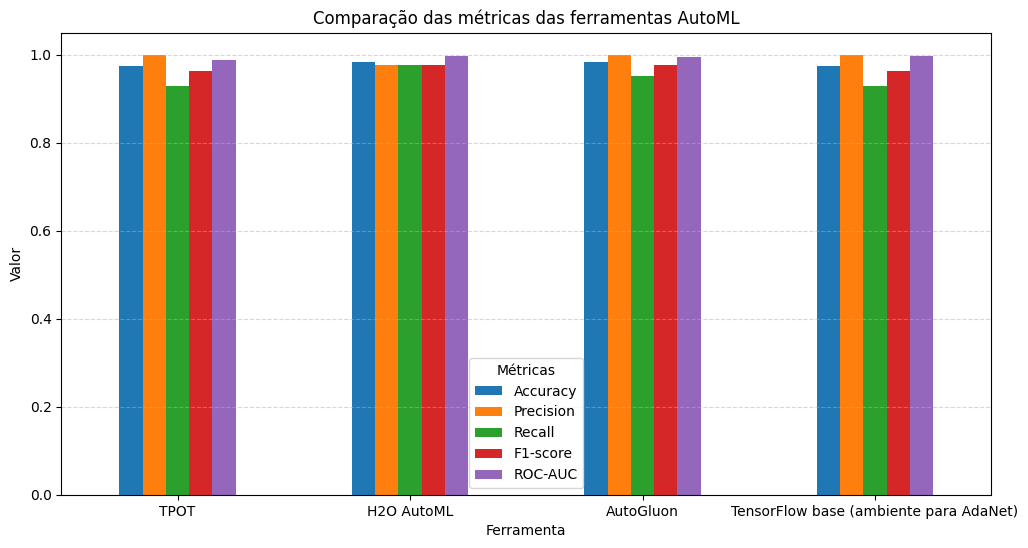

In [85]:
# visualização conjunta das métricas
def grafico_comparacao_metricas(tabela_metricas):
    tabela_plot = tabela_metricas.copy()

    # Definir a ferramenta como índice
    tabela_plot = tabela_plot.set_index("Ferramenta")

    # Escolher apenas colunas numéricas
    colunas_metricas = ["Accuracy", "Precision", "Recall", "F1-score"]
    if "ROC-AUC" in tabela_plot.columns:
        colunas_metricas.append("ROC-AUC")

    tabela_plot[colunas_metricas].plot(kind="bar", figsize=(12, 6))
    plt.title("Comparação das métricas das ferramentas AutoML")
    plt.ylabel("Valor")
    plt.xlabel("Ferramenta")
    plt.xticks(rotation=0)
    plt.ylim(0, 1.05)
    plt.legend(title="Métricas")
    plt.grid(axis="y", linestyle="--", alpha=0.5)
    plt.show()

grafico_comparacao_metricas(tabela_metricas)

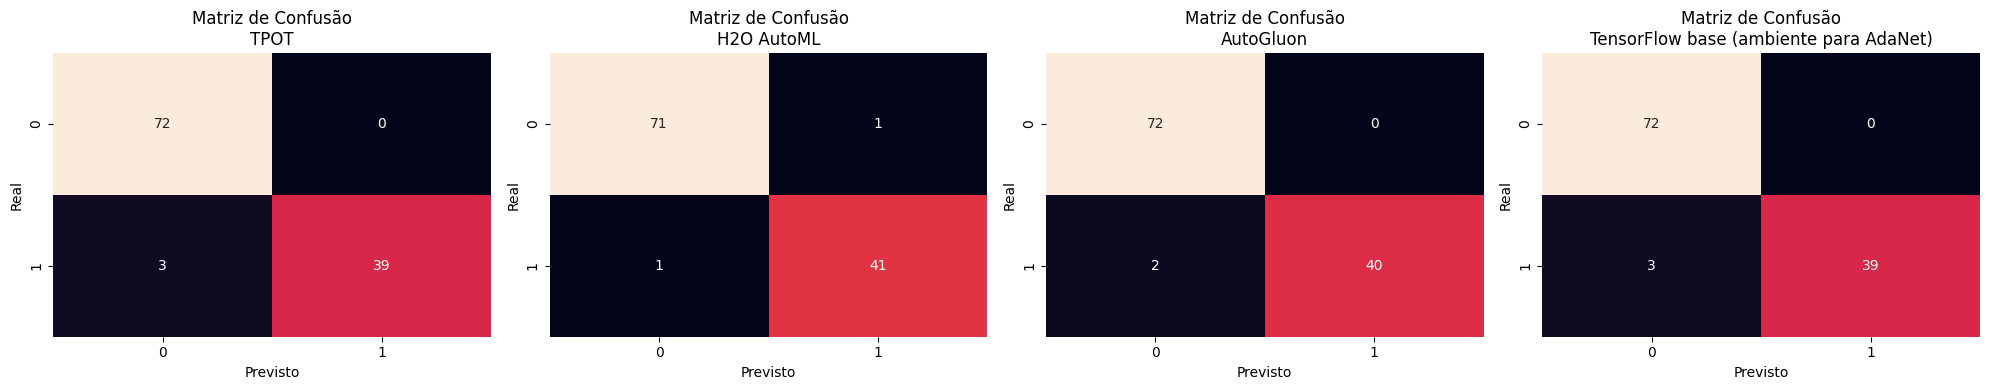

In [86]:
# matrizes de confusão

def plotar_matrizes_confusao(resultados_finais):
    n = len(resultados_finais)

    if n == 0:
        print("Não existem resultados para visualizar.")
        return

    plt.figure(figsize=(5 * n, 4))

    for i, resultado in enumerate(resultados_finais, 1):
        cm = resultado["resultados"]["Confusion_Matrix"]
        nome = resultado["resultados"]["Ferramenta"]

        plt.subplot(1, n, i)
        sns.heatmap(cm, annot=True, fmt="d", cbar=False)
        plt.title(f"Matriz de Confusão\n{nome}")
        plt.xlabel("Previsto")
        plt.ylabel("Real")

    plt.tight_layout()
    plt.show()

plotar_matrizes_confusao(resultados_finais)

In [54]:
# Tabela de comparação qualitativa
comparacao_qualitativa = pd.DataFrame({
    "Ferramenta": ["TPOT", "H2O", "AutoGluon", "AdaNet"],

    "Facilidade_configuração": [
        "Média/baixa (problemas de versão e API)",
        "Média (requer inicialização do servidor)",
        "Alta (muito simples e direto)",
        "Baixa (dependente de TensorFlow e configuração complexa)"
    ],

    "Tempo_execução": [
        "Alto (exploração evolutiva lenta)",
        "Médio (rápido com vários modelos)",
        "Baixo/Médio (muito eficiente)",
        "Médio/alto (depende da rede e treino)"
    ],

    "Pré_processamento_manual": [
        "Necessário (melhor com dados preparados)",
        "Baixo (lida bem internamente)",
        "Muito baixo (quase automático)",
        "Necessário (dados preparados manualmente)"
    ],

    "Interpretabilidade": [
        "Alta (pipeline explícito)",
        "Média (leaderboard + modelos)",
        "Média (menos transparente internamente)",
        "Baixa (modelo tipo caixa negra)"
    ],

    "Desempenho_geral": [
        "Alto (bons modelos, mas custo elevado)",
        "Muito alto (ensemble forte)",
        "Muito alto (resultados consistentes)",
        "Médio (depende da arquitetura)"
    ],

    "Observações": [
        "Problemas de compatibilidade e mudanças de API; exportação menos direta",
        "Requer ambiente H2O ativo; boa robustez",
        "Muito fácil de usar; ideal para dados tabulares",
        "Mais complexo; menos adequado para este tipo de dataset"
    ]
})

display(comparacao_qualitativa)

,Ferramenta,Facilidade_configuração,Tempo_execução,Pré_processamento_manual,Interpretabilidade,Desempenho_geral,Observações
0,TPOT,Média/baixa (problemas de versão e API),Alto (exploração evolutiva lenta),Necessário (melhor com dados preparados),Alta (pipeline explícito),"Alto (bons modelos, mas custo elevado)",Problemas de compatibilidade e mudanças de API; exportação menos direta
1,H2O,Média (requer inicialização do servidor),Médio (rápido com vários modelos),Baixo (lida bem internamente),Média (leaderboard + modelos),Muito alto (ensemble forte),Requer ambiente H2O ativo; boa robustez
2,AutoGluon,Alta (muito simples e direto),Baixo/Médio (muito eficiente),Muito baixo (quase automático),Média (menos transparente internamente),Muito alto (resultados consistentes),Muito fácil de usar; ideal para dados tabulares
3,AdaNet,Baixa (dependente de TensorFlow e configuração complexa),Médio/alto (depende da rede e treino),Necessário (dados preparados manualmente),Baixa (modelo tipo caixa negra),Médio (depende da arquitetura),Mais complexo; menos adequado para este tipo de dataset


# Estrutura de comparação entre ferramentas

Após a execução das diferentes abordagens, a comparação final poderá considerar os seguintes critérios:

1. facilidade de instalação e configuração;
2. tempo de execução;
3. necessidade de pré-processamento manual;
4. clareza dos resultados apresentados;
5. desempenho preditivo;
6. adequação a datasets tabulares;
7. robustez prática em ambiente Jupyter.

Esta perspetiva é importante porque, num dataset relativamente limpo e estruturado como este, as diferenças de desempenho podem ser pequenas, tornando ainda mais relevante a comparação da experiência prática de utilização.



A principal vantagem desta organização por funções é garantir maior consistência metodológica. Em vez de criar blocos independentes e difíceis de comparar, o notebook passa a usar o mesmo dataset, a mesma lógica de limpeza, a mesma divisão treino/teste e a mesma função de avaliação.

Dessa forma, as diferenças observadas entre TPOT, H2O, AutoGluon e AdaNet ficam mais associadas às características das próprias ferramentas do que a alterações no tratamento dos dados. Isto reforça a validade da comparação e torna o código mais limpo, mais reutilizável e mais fácil de interpretar.

## Conclusão

Ao longo deste trabalho tornou-se claro que, embora todas as ferramentas AutoML testadas apresentem bons resultados ao nível da classificação, as diferenças mais relevantes não estão propriamente no desempenho, mas sim na forma como cada ferramenta se comporta na prática.

O AutoGluon revelou-se a solução mais direta e eficiente. Com pouca configuração, foi possível obter resultados consistentes, o que mostra que é particularmente adequado para datasets tabulares bem estruturados como este. A sua principal vantagem está precisamente na simplicidade: permite concentrar o esforço na análise dos resultados e não na configuração técnica.

O H2O também apresentou um desempenho muito sólido, destacando-se pela robustez e pela variedade de modelos testados automaticamente. No entanto, exige um pouco mais de preparação inicial, nomeadamente ao nível do ambiente, o que o torna ligeiramente menos imediato do que o AutoGluon.

Já o TPOT acabou por ser a ferramenta mais exigente ao nível prático. Apesar de conseguir gerar pipelines interessantes, surgiram dificuldades relacionadas com a compatibilidade entre versões e alterações na API, o que obrigou a ajustes adicionais. Este aspeto é relevante, pois mostra que nem sempre uma ferramenta poderosa é necessariamente a mais estável ou a mais fácil de integrar num fluxo de trabalho real.

Por fim, o AdaNet revelou-se menos adequado neste contexto. A sua dependência do ecossistema TensorFlow e a complexidade associada à sua configuração tornam-no menos prático para este tipo de problema, sobretudo quando comparado com alternativas mais simples e direcionadas para dados tabulares.

Assim, mais do que identificar uma ferramenta “melhor” de forma absoluta, este trabalho mostra que a escolha depende do contexto. Para situações em que se privilegia rapidez e simplicidade, o AutoGluon destaca-se claramente. Para cenários mais robustos e estruturados, o H2O surge como uma alternativa forte. Já o TPOT e o AdaNet evidenciam que a complexidade e a estabilidade do ambiente são fatores que não devem ser ignorados na prática.